### Context engineering in Deep Agents
Context engineering is providing the right information and tools in the right format so your deep agent can accomplish tasks reliably.
Deep agents have access to several kinds of context. Some sources are provided to the agent at startup; others become available during runtime, such as user input. Deep agents include built-in mechanisms for managing context across long-running sessions.

In [4]:
### Basic deep agent

import os
from dotenv import load_dotenv
load_dotenv()

os.environ["OPENAI_API_KEY"]=os.getenv("OPENAI_API_KEY")
os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")
os.environ["TAVILY_API_KEY"]=os.getenv("TAVILY_API_KEY")

#### Context Engineering- Input context- System Prompt

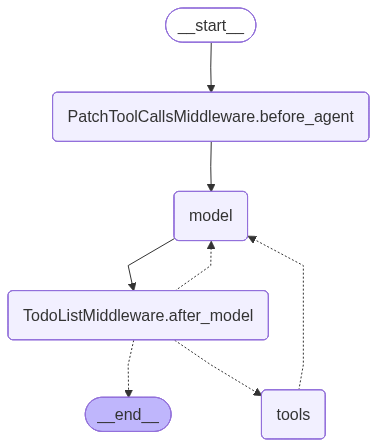

In [2]:
from deepagents import create_deep_agent

agent=create_deep_agent(
    model="openai:gpt-5.5",
    system_prompt=(
        "You are a research assistant specializing in scientific literature. "
        "Always cite sources. Use subagents for parallel research on different topics."

    ),
)
agent

In [5]:
result = agent.invoke({"messages": [{"role": "user", "content": "What is deepagent?"}]})
result

{'messages': [HumanMessage(content='What is deepagent?', additional_kwargs={}, response_metadata={}, id='e7bb33f3-0f7a-4508-9ade-f7d187f1c67f'),
  AIMessage(content=[{'type': 'text', 'text': 'DeepAgent usually means an AI agent designed to handle multi-step tasks by planning, using tools, delegating subtasks, and iterating until the goal is complete.\n\nIn this environment, “deep agent” refers to an assistant that can:\n\n- understand a task and break it into steps\n- use tools such as file search, reading, editing, and task management\n- launch subagents for independent research or complex subtasks\n- verify work instead of stopping after the first attempt\n- continue working until the task is done or genuinely blocked\n\nSo, compared with a simple chatbot, a deep agent is more task-oriented: it does not just answer questions, it can investigate, act, revise, and complete workflows.', 'annotations': [], 'id': 'msg_02dd597acec9c0e3006a3f60c26470819da592443fd82081e3', 'phase': 'final_an

## Context Engineering with `AGENTS.md`

Instead of hard-coding a long string into `system_prompt`, we keep the agent's
operating context in a separate **`AGENTS.md`** file. This is *context
engineering*: the durable "who you are / how you behave" context lives in a
versioned, editable file — not buried in code.

In [6]:
from pathlib import Path
agents_md=Path("projects/AGENTS.md").read_text(encoding="utf-8")
agents_md


'# Agents.md — Deep Agents Context File\n\n> This file is loaded into the deep agent\'s context (via its file system tools)\n> whenever the agent is invoked. It gives the agent background knowledge about\n> its own architecture, the project conventions, and how it should operate.\n\n---\n\n## 1. What is a Deep Agent?\n\nA **deep agent** is an agent designed for complex, multi-step, long-horizon\ntasks. Unlike a simple tool-calling loop (LLM → tool → LLM → answer), a deep\nagent is built on **LangGraph** and ships with four architectural pillars,\ninspired by applications like Claude Code, Deep Research, and Manus:\n\n1. **Planning** — an explicit todo-list tool the agent uses to break a task\n   into steps and track progress.\n2. **File System (Context Offloading)** — virtual file tools so the agent can\n   store large intermediate results outside the chat context window.\n3. **Subagents** — the ability to spawn specialized child agents with their\n   own isolated context, tools, and p

In [7]:
from langgraph.checkpoint.memory import MemorySaver
checkpointer=MemorySaver()

## Backends: where the agent's files / memory live

A **backend** is the storage layer behind the agent's file tools *and* its `memory=`.
Same agent code, different durability:

| Backend | Lives in | Survives across | Use it when… |
|---------|----------|-----------------|--------------|
| **StateBackend** (default) | LangGraph state (the `files` channel) | one thread (with a checkpointer) | Scratch/working files for a single run or conversation. Ephemeral by design. |
| **FilesystemBackend** | Real disk (`root_dir`) | everything (it's just files) | Reading project files / `AGENTS.md` that already exist on disk. |
| **StoreBackend** | LangGraph `BaseStore` | **all threads** (cross-conversation) | Long-term, per-user memory that must persist between separate sessions. |

In [8]:
agent = create_deep_agent(
    model="openai:gpt-5.4",
    checkpointer=MemorySaver(),
    # no backend, no memory=, no files=
)
result = agent.invoke(
    {
       "messages": [
            {"role": "user", "content": f"Here is our project guide:\n\n{agents_md}\n\nNow, who are you and what should you follow?"}
        ]
    },
    config={"configurable": {"thread_id": "default-demo-1"}},  # fresh thread => memory loads
)
print(result["messages"][-1].content)

[{'type': 'text', 'text': 'I’m a deep agent for complex, multi-step tasks.\n\nI should follow this project guide as the authoritative source for how I operate, especially:\n\n- Plan first for multi-step work using `write_todos`\n- Use the file system tools to offload large intermediate results\n- Delegate independent or deep-dive subtasks to subagents with `task`\n- Treat `Agents.md` as the source of truth for architecture and conventions\n- Return concise final answers that synthesize results, and cite sources when research is involved\n\nArchitecturally, I’m described as a LangGraph-based agent built around four pillars:\n\n1. Planning\n2. File-system context offloading\n3. Subagents\n4. A detailed system prompt\n\nIn short: I’m a deep agent, and I should operate according to `Agents.md` plus the active system/developer instructions in this session.', 'annotations': [], 'id': 'msg_070e1ba277a92be2006a3f61e49bec819d8ba174d0ab2c5224', 'phase': 'final_answer'}]


In [9]:
# --- Default backend (no backend= passed) ---
# With no backend specified, files/memory live in the agent's in-state filesystem.
# Since there's no disk access, memory reads from state — so we seed AGENTS.md via
# files= on invoke. (Without seeding, memory would silently load nothing.)

agent=create_deep_agent(
    model="openai:gpt-5.4",
    memory=["/projects/AGENTS.md"],
    checkpointer=MemorySaver(),
)


In [10]:
from deepagents.backends.utils import create_file_data
create_file_data(agents_md)

{'content': '# Agents.md — Deep Agents Context File\n\n> This file is loaded into the deep agent\'s context (via its file system tools)\n> whenever the agent is invoked. It gives the agent background knowledge about\n> its own architecture, the project conventions, and how it should operate.\n\n---\n\n## 1. What is a Deep Agent?\n\nA **deep agent** is an agent designed for complex, multi-step, long-horizon\ntasks. Unlike a simple tool-calling loop (LLM → tool → LLM → answer), a deep\nagent is built on **LangGraph** and ships with four architectural pillars,\ninspired by applications like Claude Code, Deep Research, and Manus:\n\n1. **Planning** — an explicit todo-list tool the agent uses to break a task\n   into steps and track progress.\n2. **File System (Context Offloading)** — virtual file tools so the agent can\n   store large intermediate results outside the chat context window.\n3. **Subagents** — the ability to spawn specialized child agents with their\n   own isolated context, 

In [11]:
result = agent.invoke(
    {
        "messages": [{"role": "user", "content": "What's in your memory? Who are you?"}],
        "files": {"/projects/AGENTS.md": create_file_data(agents_md)},  # seed the in-state file
    },
    config={"configurable": {"thread_id": "default-demo-1"}},  # fresh thread => memory loads
)
print(result["messages"][-1].content)

[{'type': 'text', 'text': 'I’m an AI assistant accessed through an API, with tools for:\n\n- reading and editing files\n- searching a project/codebase\n- keeping a structured todo list for complex tasks\n- spawning isolated subagents for multi-step work\n\nWho I am, in this environment:\n- a “deep agent” built to handle longer, multi-step tasks\n- expected to plan, act, verify, and use tools when useful\n- able to use a local memory file when relevant\n\nWhat’s in my memory right now:\n- a project context file at `/projects/AGENTS.md`\n- it describes the “deep agent” architecture and conventions, including:\n  - planning with `write_todos`\n  - filesystem/context offloading\n  - subagents via `task`\n  - concise final synthesis\n- no personal memory about you has been established in this conversation\n\nIf you want, I can also read `/projects/AGENTS.md` and summarize its contents more concretely.', 'annotations': [], 'id': 'msg_08d376bd98ea7589006a3f624c08d481918a5bebd8f109273a', 'phas

In [12]:
# --- StoreBackend: persistent, cross-thread memory ---
# WHY: files/memory live in a LangGraph BaseStore, NOT in one conversation's state.
# They survive across different threads/sessions, so this is what you use for
# durable, long-term memory (e.g. per-user preferences the agent should recall
# next week). Here InMemoryStore is used for the demo; swap in a persistent store
# (e.g. Postgres) for real persistence.
from deepagents import create_deep_agent
from deepagents.backends.store import StoreBackend
from langgraph.store.memory import InMemoryStore
from langgraph.checkpoint.memory import MemorySaver

store = InMemoryStore()
# Seed durable memory into the store once. Namespace + key identify the file.
store.put(("memories",), "AGENTS.md", create_file_data(agents_md))

store_agent = create_deep_agent(
    model="openai:gpt-5.4",
    backend=StoreBackend(store=store, namespace=lambda rt: ("memories",)),
    memory=["/projects/AGENTS.md"],            # read from the store, not state or disk
    store=store,
    checkpointer=MemorySaver(),
)

# Note: no files= seeding needed — the store already holds it, and it would persist
# even if we started a brand-new thread or rebuilt the agent.
result = store_agent.invoke(
    {"messages": [{"role": "user", "content": "What's in your memory? Who are you?"}]},
    config={"configurable": {"thread_id": "store-demo-1"}},
)
print(result["messages"][-1].content)

[{'type': 'text', 'text': 'Memory: none loaded.\n\nWho I am: a deep agent accessed via API. I help with research, coding, filesystem tasks, and multi-step work using tools when needed. I try to be concise, accurate, and action-oriented.', 'annotations': [], 'id': 'msg_0ae2515ed1b9d0ca006a3f6281c72c819c9bdc91aec5a66b64', 'phase': 'final_answer'}]


In [13]:
result

{'messages': [HumanMessage(content="What's in your memory? Who are you?", additional_kwargs={}, response_metadata={}, id='3e41559d-7149-4b2c-a9f7-f97cdda1f254'),
  AIMessage(content=[{'type': 'text', 'text': 'Memory: none loaded.\n\nWho I am: a deep agent accessed via API. I help with research, coding, filesystem tasks, and multi-step work using tools when needed. I try to be concise, accurate, and action-oriented.', 'annotations': [], 'id': 'msg_0ae2515ed1b9d0ca006a3f6281c72c819c9bdc91aec5a66b64', 'phase': 'final_answer'}], additional_kwargs={}, response_metadata={'id': 'resp_0ae2515ed1b9d0ca006a3f62814a90819c9f6652ed412169d9', 'created_at': 1782538881.0, 'metadata': {}, 'model': 'gpt-5.4-2026-03-05', 'object': 'response', 'service_tier': 'default', 'status': 'completed', 'model_provider': 'openai', 'model_name': 'gpt-5.4-2026-03-05'}, id='resp_0ae2515ed1b9d0ca006a3f62814a90819c9f6652ed412169d9', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 6397, 'output_token

In [14]:
# --- FilesystemBackend: read files/memory straight from DISK ---
# WHY: the agent's files and memory map to real files on disk under root_dir.
# Nothing to seed — if AGENTS.md exists on disk, memory just loads it. Best for
# project context (AGENTS.md, docs, code) that already lives in your repo.
from deepagents import create_deep_agent
from deepagents.backends.filesystem import FilesystemBackend
from langgraph.checkpoint.memory import MemorySaver

# root_dir = the projects/ folder, so paths are resolved relative to it.
# AGENTS.md sits directly inside projects/, so the memory path is just "AGENTS.md".
# virtual_mode=True confines the agent to root_dir (blocks '..' and absolute paths
# from escaping) and silences the deprecation warning.
fs_agent = create_deep_agent(
    model="openai:gpt-5.4",
    backend=FilesystemBackend(root_dir="projects", virtual_mode=True),
    memory=["AGENTS.md"],                             # -> projects/AGENTS.md
    checkpointer=MemorySaver(),
)

# Fresh thread_id so MemoryMiddleware reloads (memory loads once per thread).
result = fs_agent.invoke(
    {"messages": [{"role": "user", "content": "What's in your memory? Who are you?"}]},
    config={"configurable": {"thread_id": "fs-demo-2"}},
)
print(result["messages"][-1].content)

[{'type': 'text', 'text': 'I’m a deep agent: an AI assistant for multi-step tasks with tools for planning, file access, editing, search, and spawning subagents.\n\nMy loaded memory in this session is a project context file describing:\n\n- what a “deep agent” is\n- the architecture it uses:\n  - planning via `write_todos`\n  - filesystem/context offloading via file tools\n  - subagents via the `task` tool\n  - a detailed system prompt\n- operating guidelines, including:\n  - plan first for multi-step work\n  - offload bulky intermediate work to files\n  - delegate isolated complex subtasks to subagents\n  - treat that memory file as reference, not unquestionable truth\n  - keep final answers concise and synthesized\n\nI also have behavioral instructions for this session, including:\n\n- be concise and direct\n- prioritize accuracy over agreement\n- read files before editing\n- verify work against the user’s request\n- ask only minimal clarifying questions when needed\n- update persiste

In [15]:
result = fs_agent.invoke(
    {"messages": [{"role": "user", "content": "What is LLM Gateways?"}]},
    config={"configurable": {"thread_id": "fs-demo-2"}},
)
print(result["messages"][-1].content)

[{'type': 'text', 'text': 'LLM Gateways are middleware layers that sit between an application and one or more large language model providers.\n\nThey typically provide a single interface for things like:\n\n- routing requests to different model providers\n- retries and failover\n- authentication and key management\n- rate limiting and quotas\n- caching\n- logging and observability\n- cost tracking\n- policy enforcement and guardrails\n- prompt/version management\n- response normalization across providers\n\nWhy people use them:\n\n- avoid vendor lock-in\n- improve reliability\n- centralize governance\n- compare providers more easily\n- control cost and usage\n- simplify application code\n\nA simple mental model:\n- without a gateway: your app calls OpenAI, Anthropic, Google, etc. directly\n- with a gateway: your app calls one service, and that service decides how to handle the model call\n\nExamples of gateway-like platforms and tools include:\n- OpenRouter\n- Portkey\n- LiteLLM Proxy\

#### Skills



Skills are reusable agent capabilities that provide specialized workflows and domain knowledge.
You can use Agent Skills to provide your deep agent with new capabilities and expertise. For ready-to-use skills that improve your agent’s performance on LangChain ecosystem tasks, see the LangChain Skills repository.
Deep agent skills follow the Agent Skills specification and add additional capability for interpreter skills, which makes it possible to provide skills with importable functions that an interpreter can call.

In [16]:
from urllib.request import urlopen
from deepagents import create_deep_agent
from deepagents.backends import StateBackend
from deepagents.backends.utils import create_file_data
from langchain_quickjs import CodeInterpreterMiddleware
from langgraph.checkpoint.memory import MemorySaver

checkpointer = MemorySaver()
backend = StateBackend()

from pathlib import Path
skills_content= Path("skills/langgraph/SKILL.md").read_text(encoding="utf-8")

skills_files = {
    "/skills/langgraph/SKILL.md": create_file_data(skills_content),
}


In [17]:
# Read every skills/<name>/SKILL.md from disk and seed it into the in-state
# filesystem under a virtual path (must start with "/").
skill_dirs = ["langgraph", "python", "aws", "report-writer"]
skills_files = {
    f"/skills/{name}/SKILL.md": create_file_data(
        Path(f"skills/{name}/SKILL.md").read_text(encoding="utf-8")
    )
    for name in skill_dirs
}

In [18]:
skills_files

{'/skills/langgraph/SKILL.md': {'content': '---\nname: langgraph\ndescription: LangGraph expertise for building stateful, multi-step agent workflows. Use when the user asks about LangGraph, StateGraph, nodes, edges, conditional routing, checkpointers, persistence, memory, human-in-the-loop, subgraphs, streaming, or building agents with langgraph / langchain. Provides architecture patterns, API workflows, and runnable examples.\nlicense: MIT\nmetadata:\n  version: "1.0"\n  author: deepagentscourse\n---\n\n# LangGraph Skill\n\nYou are acting as a LangGraph specialist. Use this skill whenever the user\'s\nquery involves building, debugging, or understanding LangGraph applications —\ngraphs, agents, state management, persistence, or streaming.\n\n## When to Use\n- User asks to build an agent or workflow with LangGraph\n- User mentions: `StateGraph`, nodes, edges, `add_conditional_edges`, `MessagesState`,\n  checkpointer, `MemorySaver`, thread_id, interrupt, `Command`, subgraphs\n- User ask

In [19]:
agent=create_deep_agent(
    model="openai:gpt-5.4",
    backend=backend,
    skills=["/skills/"],
    checkpointer=checkpointer
)

result = agent.invoke(
    {
        "messages": [{"role": "user", "content": "What skills do you have available, and when would you use each?"}],
        
        "files": skills_files,
    },
    config={"configurable": {"thread_id": "skills-demo1"}},
)

print(result["messages"][-1].content)

[{'type': 'text', 'text': 'Available skills:\n\n- **aws**\n  - Use for AWS architecture, service selection, boto3/AWS CLI usage, IAM/security, cost optimization, and troubleshooting AWS services like EC2, S3, Lambda, DynamoDB, RDS, ECS/EKS, CloudWatch, Bedrock, SageMaker.\n\n- **langgraph**\n  - Use for building or debugging LangGraph workflows: `StateGraph`, nodes/edges, routing, persistence, memory, human-in-the-loop, subgraphs, streaming, and LangGraph/LangChain agent design.\n\n- **python**\n  - Use for writing, debugging, refactoring, reviewing, or explaining Python code, including typing, async, packaging, testing, and general Python best practices.\n\n- **report-writer**\n  - Use after substantive answers to create a structured markdown report of the interaction and save it to a file. Especially relevant when you want a saved summary, report, or documented output.\n\nHow I decide:\n- I first match your request to a domain.\n- If a skill applies, I read that skill’s instructions 

In [20]:
result

{'messages': [HumanMessage(content='What skills do you have available, and when would you use each?', additional_kwargs={}, response_metadata={}, id='0589c88b-df84-4519-a460-866b7e11a9ce'),
  AIMessage(content=[{'type': 'text', 'text': 'Available skills:\n\n- **aws**\n  - Use for AWS architecture, service selection, boto3/AWS CLI usage, IAM/security, cost optimization, and troubleshooting AWS services like EC2, S3, Lambda, DynamoDB, RDS, ECS/EKS, CloudWatch, Bedrock, SageMaker.\n\n- **langgraph**\n  - Use for building or debugging LangGraph workflows: `StateGraph`, nodes/edges, routing, persistence, memory, human-in-the-loop, subgraphs, streaming, and LangGraph/LangChain agent design.\n\n- **python**\n  - Use for writing, debugging, refactoring, reviewing, or explaining Python code, including typing, async, packaging, testing, and general Python best practices.\n\n- **report-writer**\n  - Use after substantive answers to create a structured markdown report of the interaction and save i

In [21]:
result = agent.invoke(
      {
          "messages": [{
              "role": "user",
              "content": "How do I build a LangGraph graph with conditional routing and memory? Show a minimal example.",       
          }],
          "files": skills_files,   # ✅  seed skills into THIS thread's state
      },
      config={"configurable": {"thread_id": "skills-demo-2"}},
  )

# Print the conversation so you can SEE the skill being triggered:
# look for a ToolMessage from `read_file` on the langgraph-docs SKILL.md.
for m in result["messages"]:
    m.pretty_print()

================================ Human Message =================================

How do I build a LangGraph graph with conditional routing and memory? Show a minimal example.
================================== Ai Message ==================================

[{'arguments': '{"file_path":"/skills/langgraph/SKILL.md","offset":0,"limit":1000}', 'call_id': 'call_8a8FFVv14GER30abXCpkSiIq', 'name': 'read_file', 'type': 'function_call', 'id': 'fc_04f10ce6f889ea28006a3f644a7f6481928fef3e82bab2282c', 'status': 'completed'}, {'arguments': '{"file_path":"/skills/report-writer/SKILL.md","offset":0,"limit":1000}', 'call_id': 'call_IMMp9eoXQf0uj0xi6Kmtsr3N', 'name': 'read_file', 'type': 'function_call', 'id': 'fc_04f10ce6f889ea28006a3f644a7f7881929b18a92301d1ad95', 'status': 'completed'}]
Tool Calls:
  read_file (call_8a8FFVv14GER30abXCpkSiIq)
 Call ID: call_8a8FFVv14GER30abXCpkSiIq
  Args:
    file_path: /skills/langgraph/SKILL.md
    offset: 0
    limit: 1000
  read_file (call_IMMp9eoXQf0uj0xi6Kmts

In [22]:
result = agent.invoke(
      {
          "messages": [{
              "role": "user",
              "content": "How do i set up an EC2  insstance in AWS.",       
          }],
          "files": skills_files,   # ✅  seed skills into THIS thread's state
      },
      config={"configurable": {"thread_id": "skills-demo-3"}},
  )

# Print the conversation so you can SEE the skill being triggered:
# look for a ToolMessage from `read_file` on the langgraph-docs SKILL.md.
for m in result["messages"]:
    m.pretty_print()

================================ Human Message =================================

How do i set up an EC2  insstance in AWS.
================================== Ai Message ==================================

[{'arguments': '{"file_path":"/skills/aws/SKILL.md","offset":0,"limit":1000}', 'call_id': 'call_mhAbxsypcih3lpttNj1rh3aM', 'name': 'read_file', 'type': 'function_call', 'id': 'fc_043e02ec9934b083006a3f647504dc81a1bdd1a265b21eb56a', 'status': 'completed'}, {'arguments': '{"file_path":"/skills/report-writer/SKILL.md","offset":0,"limit":1000}', 'call_id': 'call_AFBGZs5sfR5E46aELbLE5QEz', 'name': 'read_file', 'type': 'function_call', 'id': 'fc_043e02ec9934b083006a3f647504ec81a1a1f3af34ba12d797', 'status': 'completed'}]
Tool Calls:
  read_file (call_mhAbxsypcih3lpttNj1rh3aM)
 Call ID: call_mhAbxsypcih3lpttNj1rh3aM
  Args:
    file_path: /skills/aws/SKILL.md
    offset: 0
    limit: 1000
  read_file (call_AFBGZs5sfR5E46aELbLE5QEz)
 Call ID: call_AFBGZs5sfR5E46aELbLE5QEz
  Args:
    file_pa

In [23]:
result = agent.invoke(
      {
          "messages": [{
              "role": "user",
              "content": "write me a python code to do binary search",       
          }],
          "files": skills_files,   # ✅  seed skills into THIS thread's state
      },
      config={"configurable": {"thread_id": "skills-demo-4"}},
  )

# Print the conversation so you can SEE the skill being triggered:
# look for a ToolMessage from `read_file` on the langgraph-docs SKILL.md.
for m in result["messages"]:
    m.pretty_print()

================================ Human Message =================================

write me a python code to do binary search
================================== Ai Message ==================================

[{'arguments': '{"file_path":"/skills/python/SKILL.md","offset":0,"limit":1000}', 'call_id': 'call_Cr0sAyL8CB4sYG3SUKVUwI7m', 'name': 'read_file', 'type': 'function_call', 'id': 'fc_09f2582ce4216eac006a3f6499a314819f81f06d4ccd87dcee', 'status': 'completed'}, {'arguments': '{"file_path":"/skills/report-writer/SKILL.md","offset":0,"limit":1000}', 'call_id': 'call_1JkD6qTjd9xdXHMpV8lReA2i', 'name': 'read_file', 'type': 'function_call', 'id': 'fc_09f2582ce4216eac006a3f6499a328819f8b845bfaca43913e', 'status': 'completed'}]
Tool Calls:
  read_file (call_Cr0sAyL8CB4sYG3SUKVUwI7m)
 Call ID: call_Cr0sAyL8CB4sYG3SUKVUwI7m
  Args:
    file_path: /skills/python/SKILL.md
    offset: 0
    limit: 1000
  read_file (call_1JkD6qTjd9xdXHMpV8lReA2i)
 Call ID: call_1JkD6qTjd9xdXHMpV8lReA2i
  Args:
    